# Model Evaluation — Knowing If Your Model Actually Works

Training a model is only half the job.  
The other half is **knowing whether it works, where it fails, and how to fix it**.

| Section | Topic | Used For |
|---|---|---|
| 1 | Why Accuracy Is Misleading | Every classification problem |
| 2 | Confusion Matrix | Classification diagnostics |
| 3 | Precision, Recall, F1 | Imbalanced classes |
| 4 | ROC Curve & AUC | Threshold-independent evaluation |
| 5 | Regression Metrics | MSE, RMSE, MAE, R² |
| 6 | Cross-Validation | Reliable generalization estimate |
| 7 | Bias-Variance Tradeoff | Diagnosing under/overfitting |
| 8 | Learning Curves | Knowing when to get more data |
| 9 | Evaluation for Deep Learning | Train/val/test, early stopping |
| 10 | Evaluation for LLMs & GenAI | Perplexity, BLEU, ROUGE, human eval |

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_curve, auc, mean_squared_error,
                              mean_absolute_error, r2_score)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 1. Why Accuracy Is Misleading

Consider a **fraud detection** model: 99% of transactions are legitimate, 1% are fraud.

A model that predicts "not fraud" for **every single transaction** gets 99% accuracy.  
But it catches **0 frauds** — completely useless.

This is the **accuracy paradox**. It happens whenever classes are imbalanced.

| Scenario | Imbalanced? | Use Instead |
|---|---|---|
| Spam detection | Yes (most is ham) | Precision + Recall |
| Disease screening | Yes (rare disease) | Recall (catch all cases) |
| Fraud detection | Very yes | F1, AUC-ROC |
| Image classification (balanced) | No | Accuracy is fine |

=== Accuracy Paradox: Fraud Detection ===
Dataset: 990 legitimate, 10 fraudulent

Dumb model (predict all 0):
  Accuracy: 99.0%  ← looks great!
  Frauds caught: 0 / 10  ← actually terrible

Decent model:
  Accuracy:      99.5%
  Frauds caught: 8 / 10


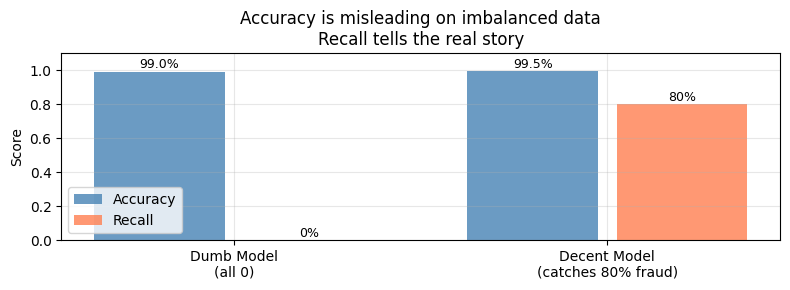

In [17]:
# Imbalanced dataset: 990 negatives, 10 positives (1% fraud)
np.random.seed(42)
y_true = np.array([0]*990 + [1]*10)

# A "dumb" model: always predicts 0
y_dumb = np.zeros_like(y_true)

# A decent model: catches 8 of 10 frauds but has some false alarms
y_decent = np.zeros_like(y_true)
fraud_idx = np.where(y_true == 1)[0]
y_decent[fraud_idx[:8]] = 1    # catches 8 frauds
y_decent[[5, 50, 150]] = 1     # 3 false alarms

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("=== Accuracy Paradox: Fraud Detection ===")
print(f"Dataset: {sum(y_true==0)} legitimate, {sum(y_true==1)} fraudulent")
print()
print("Dumb model (predict all 0):")
print(f"  Accuracy: {accuracy(y_true, y_dumb):.1%}  ← looks great!")
print(f"  Frauds caught: 0 / {sum(y_true==1)}  ← actually terrible")
print()
print("Decent model:")
print(f"  Accuracy:      {accuracy(y_true, y_decent):.1%}")
print(f"  Frauds caught: {sum((y_decent==1) & (y_true==1))} / {sum(y_true==1)}")

fig, ax = plt.subplots(figsize=(8, 3))
models = ['Dumb Model\n(all 0)',
          'Decent Model\n(catches 80% fraud)']
accs   = [accuracy(y_true, y_dumb), accuracy(y_true, y_decent)]
recalls= [0, sum((y_decent==1) & (y_true==1))/sum(y_true==1)]
x = np.arange(2)
ax.bar(x-0.2, accs,    0.35, label='Accuracy',  color='steelblue', alpha=0.8)
ax.bar(x+0.2, recalls, 0.35, label='Recall',    color='coral',     alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Accuracy is misleading on imbalanced data\nRecall tells the real story')
ax.legend()
for i, (a, r) in enumerate(zip(accs, recalls)):
    ax.text(i-0.2, a+0.02, f'{a:.1%}', ha='center', fontsize=9)
    ax.text(i+0.2, r+0.02, f'{r:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Confusion Matrix

The confusion matrix shows **where** your model is making mistakes.

```
                  Predicted
                  Negative  Positive
Actual  Negative  [ TN       FP ]   ← FP = False Alarm
        Positive  [ FN       TP ]   ← FN = Missed case
```

- **TP** (True Positive): Correct positive
- **TN** (True Negative): Correct negative
- **FP** (False Positive): False alarm — said positive, was negative
- **FN** (False Negative): Missed — said negative, was positive

> In medicine: FN (missed cancer) is usually worse than FP (unnecessary test).  
> In spam: FP (real email marked spam) is usually worse than FN (spam gets through).

=== Confusion Matrix ===
                  Predicted
                  NotSpam   Spam
Actual  NotSpam        6      2   (FP = real email → spam folder)
        Spam           2      5   (FN = spam got through)

TP=5  FP=2  TN=6  FN=2


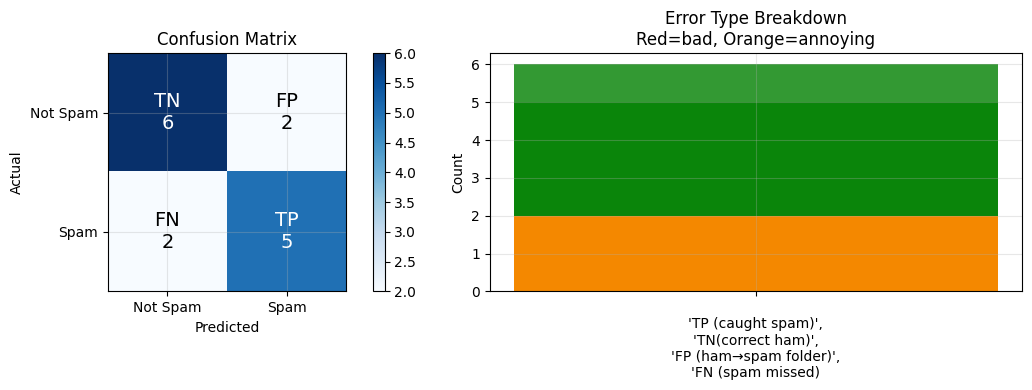

In [18]:
# Realistic spam classifier predictions
y_true = np.array([0,1,0,1,0,0,1,1,0,1,1,0,0,1,0])
y_pred = np.array([0,1,0,0,1,0,1,1,0,1,0,0,1,1,0])

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix ===")
print("                  Predicted")
print("                  NotSpam   Spam")
print(f"Actual  NotSpam   {tn:6d}   {fp:4d}   (FP = real email → spam folder)")
print(f"        Spam      {fn:6d}   {tp:4d}   (FN = spam got through)")
print()
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Not Spam', 'Spam'])
axes[0].set_yticklabels(['Not Spam', 'Spam'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        label = ['TN','FP','FN','TP'][i*2+j]
        axes[0].text(j, i, f'{label}\n{cm[i,j]}', ha='center', va='center',
                    fontsize=14, color='white' if cm[i,j] > cm.max()*0.6 else 'black')
plt.colorbar(im, ax=axes[0])

# What errors cost
error_types = ["""
'TP (caught spam)',
'TN(correct ham)',
'FP (ham→spam folder)',
'FN (spam missed)"""]
counts = [tp, tn, fp, fn]
colors = ['green', 'green', 'red', 'orange']
axes[1].bar(error_types, counts, color=colors, alpha=0.8)
axes[1].set_title('Error Type Breakdown\nRed=bad, Orange=annoying')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 3. Precision, Recall & F1

$$\text{Precision} = \frac{TP}{TP+FP} \quad \text{"Of what I said was positive, how many were?"}$$

$$\text{Recall} = \frac{TP}{TP+FN} \quad \text{"Of all actual positives, how many did I find?"}$$

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

### The Precision-Recall Tradeoff
Adjusting the **classification threshold** trades precision for recall:
- Lower threshold → catch more positives → higher recall, lower precision
- Higher threshold → be more certain → higher precision, lower recall

**Which matters more depends on the problem:**
- Cancer screening: **Recall** (missing a case is fatal)
- Spam filter: **Precision** (wrong positives annoy users)

### Precision: The 'Purity' of Positive Predictions

Measures the accuracy of positive predictions. It answers the question, “Of all the items the model labeled as positive, how many were actually positive?”
<br/><br/>
**Question**: Of all the emails the model flagged as spam, what fraction were *actually* spam?

`Precision = TP / (TP + FP)`

A high precision means the model is trustworthy when it says something is spam (it generates few false positives).

In [19]:
precision = precision_score(y_true, y_pred)
print(f"Precision: {precision:.2f}")

Precision: 0.71


### Recall (Sensitivity): Finding All the Positives

Measures the model’s ability to find all the positive instances. It answers the question, “Of all the actual positives, how many did the model correctly identify?”
<br/><br/>
**Question**: Of all the emails that were *actually* spam, what fraction did the model correctly identify?

`Recall = TP / (TP + FN)`

A high recall means the model is good at finding all the spam emails (it generates few false negatives).

In [20]:
recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.2f}")

Recall: 0.71


### F1-Score: The Harmonic Mean

The harmonic mean of precision and recall. It balances the two metrics into a single number, making it especially useful when precision and recall are in trade-off.
<br/><br/>
Often, there's a tradeoff between precision and recall. The F1-score provides a single metric that balances both.

`F1 = 2 * (Precision * Recall) / (Precision + Recall)`

It's the harmonic mean of precision and recall, and it gives a better measure of a model's performance than accuracy on imbalanced datasets.

In [21]:
f1 = f1_score(y_true, y_pred)
print(f"F1-Score: {f1:.2f}")

F1-Score: 0.71


=== Precision-Recall at Different Thresholds ===
Best F1=0.843 at threshold=0.52
  Precision=0.805  Recall=0.885


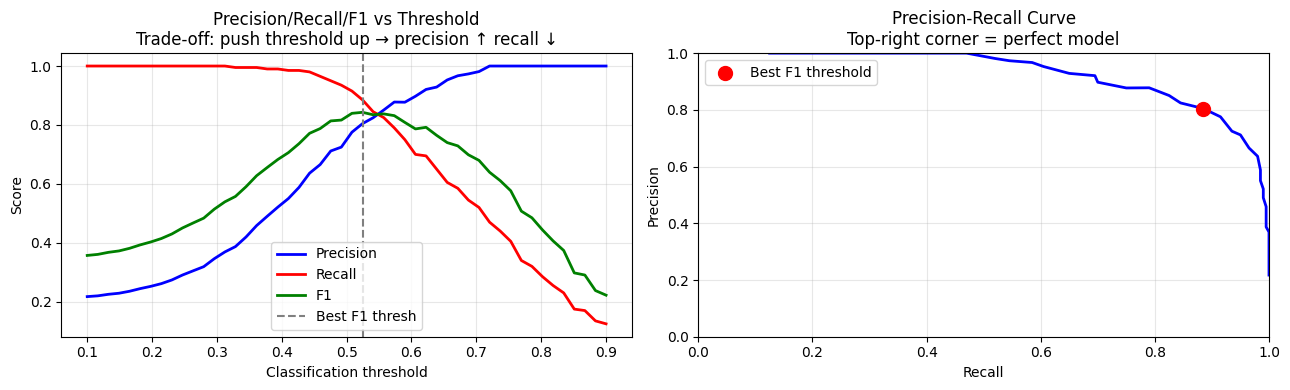

In [22]:
# Precision-recall tradeoff
np.random.seed(0)
n_pos, n_neg = 200, 800
scores_pos = np.random.normal(0.7, 0.15, n_pos)  # true positives
scores_neg = np.random.normal(0.3, 0.15, n_neg)  # true negatives
scores = np.concatenate([scores_pos, scores_neg])
y_true_pr = np.array([1]*n_pos + [0]*n_neg)

thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (scores >= thresh).astype(int)
    if y_pred_t.sum() == 0:
        precisions.append(1.0)
        recalls.append(0.0)
        f1s.append(0.0)
        continue
    p = precision_score(y_true_pr, y_pred_t, zero_division=0)
    r = recall_score(y_true_pr, y_pred_t)
    f = f1_score(y_true_pr, y_pred_t)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

best_thresh_idx = np.argmax(f1s)
print("=== Precision-Recall at Different Thresholds ===")
print(f"Best F1={f1s[best_thresh_idx]:.3f} at threshold={thresholds[best_thresh_idx]:.2f}")
print(f"  Precision={precisions[best_thresh_idx]:.3f}  Recall={recalls[best_thresh_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Threshold sweep
axes[0].plot(thresholds, precisions, 'b-', lw=2, label='Precision')
axes[0].plot(thresholds, recalls, 'r-', lw=2, label='Recall')
axes[0].plot(thresholds, f1s, 'g-', lw=2, label='F1')
axes[0].axvline(thresholds[best_thresh_idx], color='gray', linestyle='--', label='Best F1 thresh')
axes[0].set_xlabel('Classification threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision/Recall/F1 vs Threshold\nTrade-off: push threshold up → precision ↑ recall ↓')
axes[0].legend()

# PR curve
axes[1].plot(recalls, precisions, 'b-', lw=2)
axes[1].scatter(recalls[best_thresh_idx], precisions[best_thresh_idx],
                color='red', s=100, zorder=5, label='Best F1 threshold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve\nTop-right corner = perfect model')
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. ROC Curve & AUC

**ROC (Receiver Operating Characteristic)** plots:
- X-axis: False Positive Rate = FP / (FP + TN)
- Y-axis: True Positive Rate (Recall) = TP / (TP + FN)

At every possible threshold. **AUC (Area Under Curve):**
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random guessing (diagonal line)
- AUC < 0.5 → worse than random

**Advantage over F1:** AUC is threshold-independent — measures overall discriminating ability.

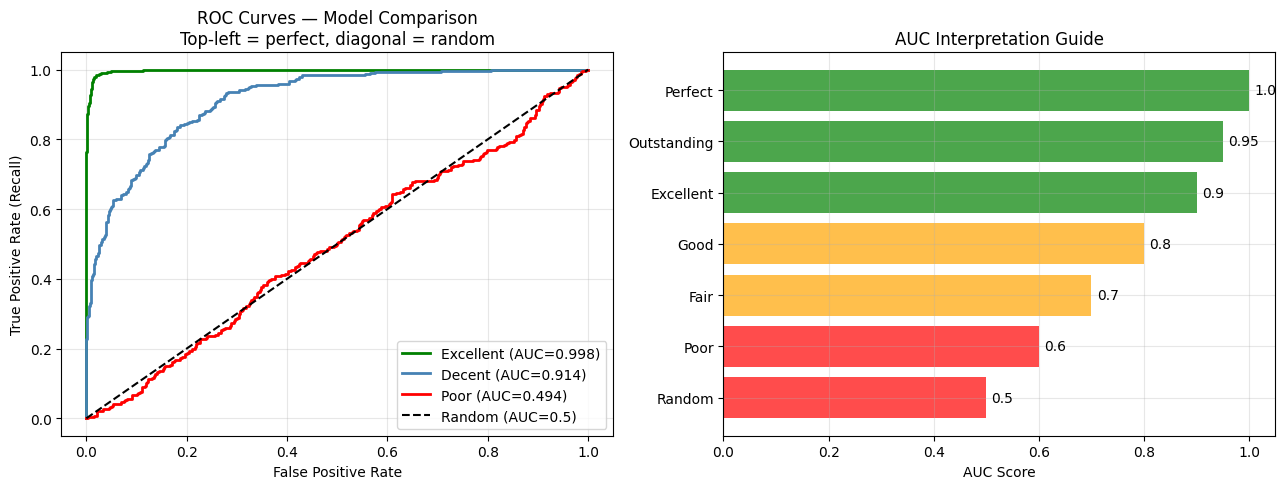

Excellent model AUC: 0.9980
AUC = probability that model ranks a random positive higher than a random negative


In [23]:
# Compare multiple models with ROC curves
np.random.seed(0)
n = 1000
y_true_roc = np.array([1]*300 + [0]*700)

# Simulate model probability scores
scores_excellent = np.where(y_true_roc==1,
    np.random.beta(8,2,n), np.random.beta(2,8,n))
scores_decent    = np.where(y_true_roc==1,
    np.random.beta(4,2,n), np.random.beta(2,4,n))
scores_poor      = np.where(y_true_roc==1,
    np.random.beta(2,2,n), np.random.beta(2,2,n))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for scores, label, color in [
    (scores_excellent, 'Excellent', 'green'),
    (scores_decent,    'Decent',    'steelblue'),
    (scores_poor,      'Poor',      'red'),
]:
    fpr, tpr, _ = roc_curve(y_true_roc, scores)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={roc_auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Model Comparison\nTop-left = perfect, diagonal = random')
axes[0].legend()

# AUC interpretation guide
auc_vals   = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
auc_labels = ['Random', 'Poor', 'Fair', 'Good', 'Excellent', 'Outstanding', 'Perfect']
colors_bar = ['red','red','orange','orange','green','green','green']
axes[1].barh(auc_labels, auc_vals, color=colors_bar, alpha=0.7)
axes[1].set_xlabel('AUC Score')
axes[1].set_title('AUC Interpretation Guide')
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(auc_vals):
    axes[1].text(v+0.01, i, f'{v}', va='center')

plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_true_roc, scores_excellent)
print(f"Excellent model AUC: {auc(fpr, tpr):.4f}")
print("AUC = probability that model ranks a random positive higher than a random negative")

---
## 5. Regression Metrics

For regression (predicting a continuous value):

| Metric | Formula | Sensitive to outliers? | Interpretable? |
|---|---|---|---|
| **MSE** | `mean((y-ŷ)²)` | Yes (squares errors) | Units² |
| **RMSE** | `√MSE` | Yes | Same units as y |
| **MAE** | `mean(|y-ŷ|)` | No | Same units as y |
| **R²** | `1 - SS_res/SS_tot` | Somewhat | 0–1 scale |
| **MAPE** | `mean(|y-ŷ|/y) × 100` | No | % error |

**R² (coefficient of determination):** How much variance in y does the model explain?  
- R²=1.0: perfect predictions
- R²=0.0: model is no better than predicting the mean
- R²<0.0: model is worse than the mean

=== Regression Metrics Comparison ===
Model A (consistent):
  MSE:     22.65  ← large because it squares errors
  RMSE:     4.76  ← in same units as y (most common)
  MAE:      3.78  ← robust to outliers
  R²:     0.9457  ← 94.6% of variance explained
  MAPE:    3.89%

Model B (outlier errors):
  MSE:    101.45  ← large because it squares errors
  RMSE:    10.07  ← in same units as y (most common)
  MAE:      4.09  ← robust to outliers
  R²:     0.7569  ← 75.7% of variance explained
  MAPE:    4.35%


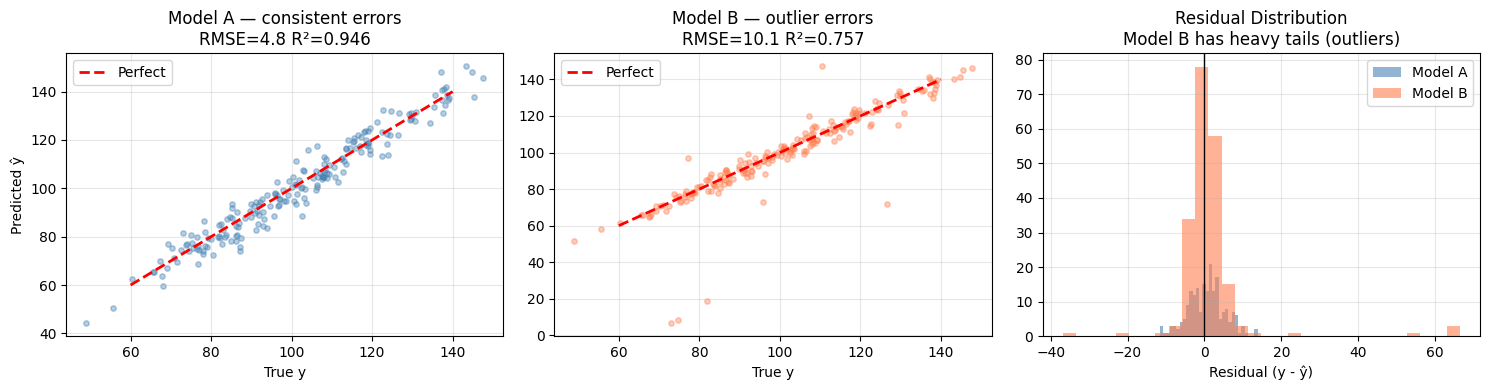

In [24]:
# Compare regression metrics on different error profiles
np.random.seed(0)
n = 200
y_true_reg = np.random.normal(100, 20, n)

# Model A: consistent small errors
y_pred_A = y_true_reg + np.random.normal(0, 5, n)
# Model B: usually good but some large outlier errors
errors_B = np.random.normal(0, 3, n)
errors_B[np.random.choice(n, 10)] += np.random.normal(0, 40, 10)  # outliers
y_pred_B = y_true_reg + errors_B

def regression_metrics(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    print(f"{name}:")
    print(f"  MSE:  {mse:8.2f}  ← large because it squares errors")
    print(f"  RMSE: {rmse:8.2f}  ← in same units as y (most common)")
    print(f"  MAE:  {mae:8.2f}  ← robust to outliers")
    print(f"  R²:   {r2:8.4f}  ← {r2*100:.1f}% of variance explained")
    print(f"  MAPE: {mape:7.2f}%")
    return rmse, mae, r2

print("=== Regression Metrics Comparison ===")
rmse_a, mae_a, r2_a = regression_metrics(y_true_reg, y_pred_A, "Model A (consistent)")
print()
rmse_b, mae_b, r2_b = regression_metrics(y_true_reg, y_pred_B, "Model B (outlier errors)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_true_reg, y_pred_A, alpha=0.4, s=15, color='steelblue')
axes[0].plot([60,140],[60,140],'r--', lw=2, label='Perfect')
axes[0].set_title(f'Model A — consistent errors\nRMSE={rmse_a:.1f} R²={r2_a:.3f}')
axes[0].set_xlabel('True y')
axes[0].set_ylabel('Predicted ŷ')
axes[0].legend()

axes[1].scatter(y_true_reg, y_pred_B, alpha=0.4, s=15, color='coral')
axes[1].plot([60,140],[60,140],'r--', lw=2, label='Perfect')
axes[1].set_title(f'Model B — outlier errors\nRMSE={rmse_b:.1f} R²={r2_b:.3f}')
axes[1].set_xlabel('True y')
axes[1].legend()

residuals_a = y_true_reg - y_pred_A
residuals_b = y_true_reg - y_pred_B
axes[2].hist(residuals_a, bins=30, alpha=0.6, color='steelblue', label='Model A')
axes[2].hist(residuals_b, bins=30, alpha=0.6, color='coral', label='Model B')
axes[2].axvline(0, color='k', lw=1)
axes[2].set_title('Residual Distribution\nModel B has heavy tails (outliers)')
axes[2].set_xlabel('Residual (y - ŷ)')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 6. Cross-Validation

**The problem with a single train/test split:**  
You might get lucky or unlucky with which data ends up in the test set.

**Cross-validation** solves this by rotating through multiple splits:

```
k-fold (k=5):
  Fold 1:  [Test ] [Train] [Train] [Train] [Train]
  Fold 2:  [Train] [Test ] [Train] [Train] [Train]
  Fold 3:  [Train] [Train] [Test ] [Train] [Train]
  Fold 4:  [Train] [Train] [Train] [Test ] [Train]
  Fold 5:  [Train] [Train] [Train] [Train] [Test ]
  
  Final score = mean of 5 test scores
```

Result: much more reliable estimate of true model performance.

=== Cross-Validation vs Single Split ===
Single split (20 random seeds):
  Mean: 0.8885  Std: 0.0305
  Range: [0.8400, 0.9400]

5-Fold Cross-Validation:
  Scores: [0.9  0.89 0.9  0.88 0.87]
  Mean: 0.8880  Std: 0.0117
  Final report: 0.888 ± 0.012


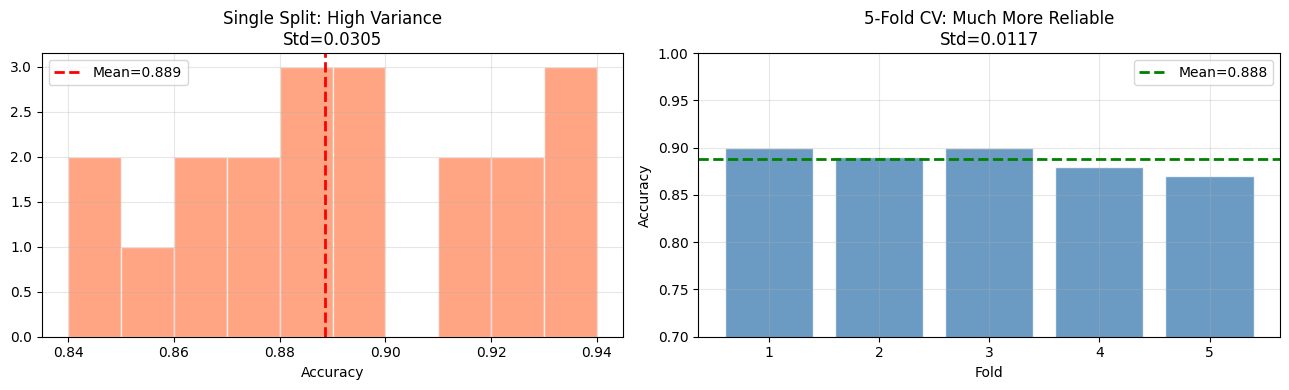

In [25]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

# Create a dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Single train/test split (unreliable)
single_scores = []
for seed in range(20):
    np.random.seed(seed)
    idx = np.random.permutation(len(X))
    X_tr, X_te = X[idx[:400]], X[idx[400:]]
    y_tr, y_te = y[idx[:400]], y[idx[400:]]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)
    single_scores.append(model.score(X_te, y_te))

# 5-fold cross-validation
model_cv = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(model_cv, X, y, cv=5)

print("=== Cross-Validation vs Single Split ===")
print("Single split (20 random seeds):")
print(f"  Mean: {np.mean(single_scores):.4f}  Std: {np.std(single_scores):.4f}")
print(f"  Range: [{min(single_scores):.4f}, {max(single_scores):.4f}]")
print()
print("5-Fold Cross-Validation:")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")
print(f"  Final report: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(single_scores, bins=10, color='coral', alpha=0.7, edgecolor='white')
axes[0].axvline(np.mean(single_scores), color='red', lw=2, linestyle='--',
                label=f'Mean={np.mean(single_scores):.3f}')
axes[0].set_title(f'Single Split: High Variance\nStd={np.std(single_scores):.4f}')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

axes[1].bar(range(1,6), cv_scores, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axhline(cv_scores.mean(), color='green', lw=2, linestyle='--',
                label=f'Mean={cv_scores.mean():.3f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'5-Fold CV: Much More Reliable\nStd={cv_scores.std():.4f}')
axes[1].set_ylim(0.7, 1.0)
axes[1].legend()
axes[1].set_xticks(range(1,6))

plt.tight_layout()
plt.show()

---
## 7. Bias-Variance Tradeoff

Every model error decomposes into three parts:

$$\text{Error} = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\text{Noise}}_{\text{irreducible}}$$

| | Bias | Variance | Symptom |
|---|---|---|---|
| **Too simple** | High | Low | Underfitting — bad on train AND test |
| **Too complex** | Low | High | Overfitting — great on train, bad on test |
| **Just right** | Moderate | Moderate | Good generalization |

**The fix:**
- High bias → more complex model, more features
- High variance → regularization, more data, simpler model

This is one of the most fundamental concepts in machine learning. It helps us diagnose our model's errors.

- **Bias**: The error from incorrect assumptions in the learning algorithm. High bias can cause the model to miss the relevant relations between features and target outputs (**underfitting**).
- **Variance**: The error from sensitivity to small fluctuations in the training set. High variance can cause the model to model the random noise in the training data, rather than the intended outputs (**overfitting**).

**The Goal**: Find a balance. A simple model has high bias and low variance. A complex model has low bias and high variance.

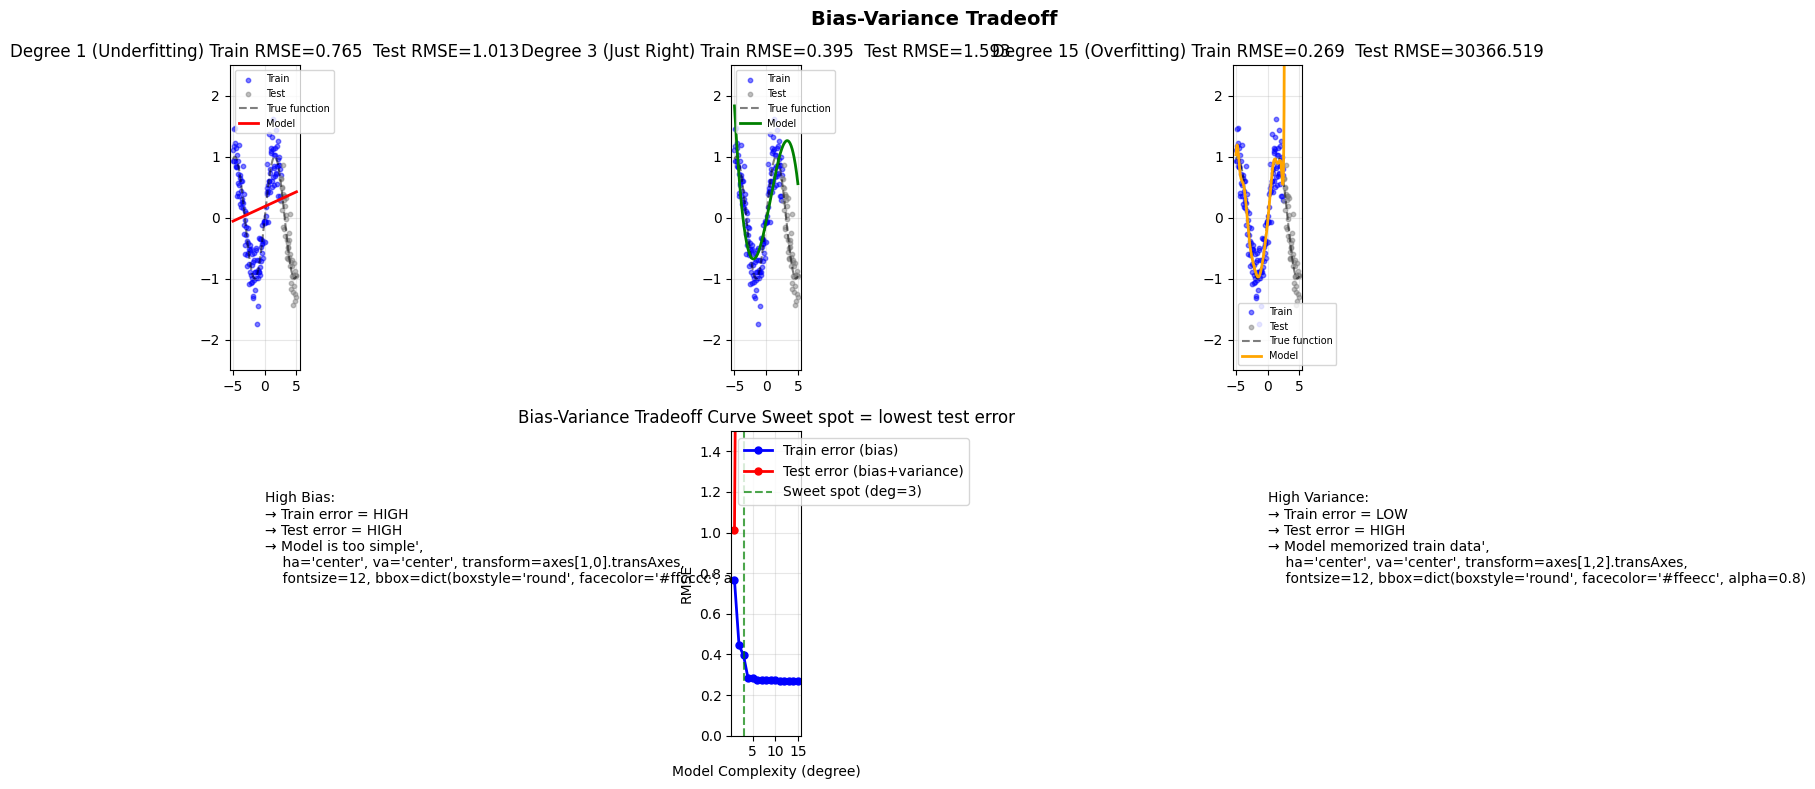

In [26]:
np.random.seed(42)
x_all = np.linspace(-5, 5, 200)
y_all = np.sin(x_all) + np.random.normal(0, 0.3, 200)

x_train, y_train = x_all[:150], y_all[:150]
x_test,  y_test  = x_all[150:], y_all[150:]

degrees = [1, 3, 15]
labels  = ['Degree 1 (Underfitting)', 'Degree 3 (Just Right)', 'Degree 15 (Overfitting)']
colors  = ['red', 'green', 'orange']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

train_errors, test_errors = [], []
for i, deg in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(x_train.reshape(-1,1), y_train)
    y_pred_train = model.predict(x_train.reshape(-1,1))
    y_pred_test  = model.predict(x_test.reshape(-1,1))
    y_pred_all   = model.predict(x_all.reshape(-1,1))

    tr_err = np.sqrt(mean_squared_error(y_train, y_pred_train))
    te_err = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    train_errors.append(tr_err)
    test_errors.append(te_err)

    axes[0, i].scatter(x_train, y_train, s=10, alpha=0.5, color='blue', label='Train')
    axes[0, i].scatter(x_test,  y_test,  s=10, alpha=0.5, color='gray', label='Test')
    axes[0, i].plot(x_all, np.sin(x_all), 'k--', lw=1.5, alpha=0.5, label='True function')
    axes[0, i].plot(x_all, y_pred_all, color=colors[i], lw=2, label='Model')
    axes[0, i].set_title(f'{labels[i]} Train RMSE={tr_err:.3f}  Test RMSE={te_err:.3f}')
    axes[0, i].set_ylim(-2.5, 2.5)
    axes[0, i].legend(fontsize=7)

# Bias-variance visualization
deg_range = range(1, 16)
tr_errs, te_errs = [], []
for d in deg_range:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(x_train.reshape(-1,1), y_train)
    tr_errs.append(np.sqrt(mean_squared_error(y_train, m.predict(x_train.reshape(-1,1)))))
    te_errs.append(np.sqrt(mean_squared_error(y_test,  m.predict(x_test.reshape(-1,1)))))

ax = axes[1, 1]
ax.plot(deg_range, tr_errs, 'b-o', ms=5, lw=2, label='Train error (bias)')
ax.plot(deg_range, te_errs, 'r-o', ms=5, lw=2, label='Test error (bias+variance)')
ax.axvline(3, color='green', linestyle='--', alpha=0.7, label='Sweet spot (deg=3)')
ax.set_xlabel('Model Complexity (degree)')
ax.set_ylabel('RMSE')
ax.set_title('Bias-Variance Tradeoff Curve Sweet spot = lowest test error')
ax.set_ylim(0, 1.5)
ax.legend()

axes[1, 0].text(0.5, 0.5,
"""High Bias:
→ Train error = HIGH
→ Test error = HIGH
→ Model is too simple',
    ha='center', va='center', transform=axes[1,0].transAxes,
    fontsize=12, bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8)""")
axes[1, 0].axis('off')

axes[1, 2].text(0.5, 0.5,
"""High Variance:
→ Train error = LOW
→ Test error = HIGH
→ Model memorized train data',
    ha='center', va='center', transform=axes[1,2].transAxes,
    fontsize=12, bbox=dict(boxstyle='round', facecolor='#ffeecc', alpha=0.8)""")
axes[1, 2].axis('off')

plt.suptitle('Bias-Variance Tradeoff', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

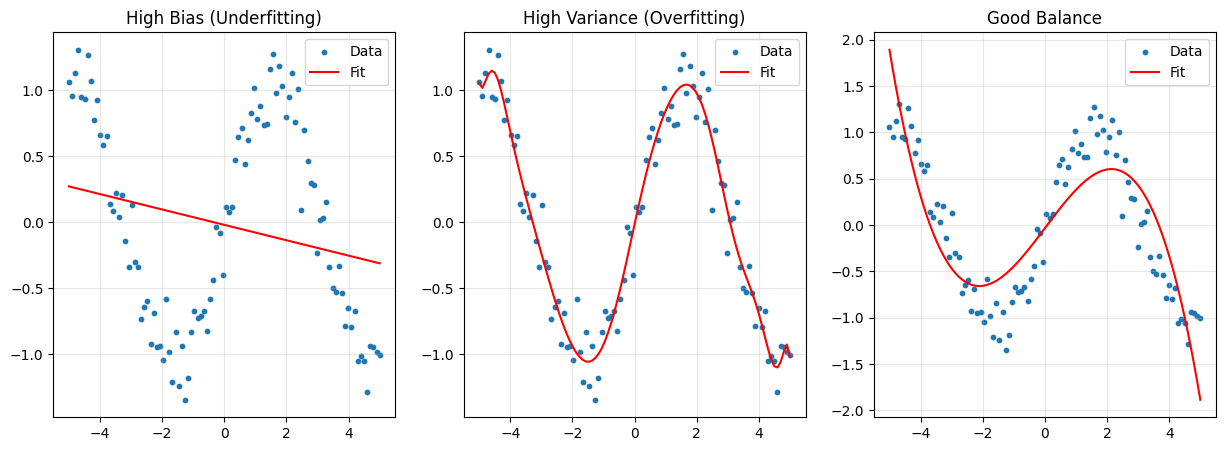

In [27]:
# Let's create a synthetic dataset with a non-linear relationship
np.random.seed(42)
x = np.linspace(-5, 5, 100)
y_true = np.sin(x) + np.random.normal(0, 0.2, 100)

# --- Model 1: Low Complexity (High Bias, Low Variance) ---
# This is a simple linear model (degree 1 polynomial)
p1 = np.polyfit(x, y_true, 1)
y_pred1 = np.polyval(p1, x)

# --- Model 2: High Complexity (Low Bias, High Variance) ---
# This is a very complex model (degree 15 polynomial)
p15 = np.polyfit(x, y_true, 15)
y_pred15 = np.polyval(p15, x)

# --- Model 3: 'Just Right' ---
# This model's complexity is close to the true function
p3 = np.polyfit(x, y_true, 3)
y_pred3 = np.polyval(p3, x)

# --- Visualization ---
plt.figure(figsize=(15, 5))

# Underfitting
plt.subplot(1, 3, 1)
plt.scatter(x, y_true, s=10, label='Data')
plt.plot(x, y_pred1, color='red', label='Fit')
plt.title('High Bias (Underfitting)')
plt.legend()

# Overfitting
plt.subplot(1, 3, 2)
plt.scatter(x, y_true, s=10, label='Data')
plt.plot(x, y_pred15, color='red', label='Fit')
plt.title('High Variance (Overfitting)')
plt.legend()

# Good Fit
plt.subplot(1, 3, 3)
plt.scatter(x, y_true, s=10, label='Data')
plt.plot(x, y_pred3, color='red', label='Fit')
plt.title('Good Balance')
plt.legend()

plt.show()

---
## 8. Learning Curves

A **learning curve** plots model performance vs training set size.  
It tells you: **is the problem data or model?**

| Pattern | Diagnosis | Fix |
|---|---|---|
| Train and test both high error | High bias (underfitting) | More complex model |
| Large gap between train and test | High variance (overfitting) | More data OR regularize |
| Both errors low, small gap | Good generalization | Ship it |
| Test error plateaued | More data won't help | Change model |

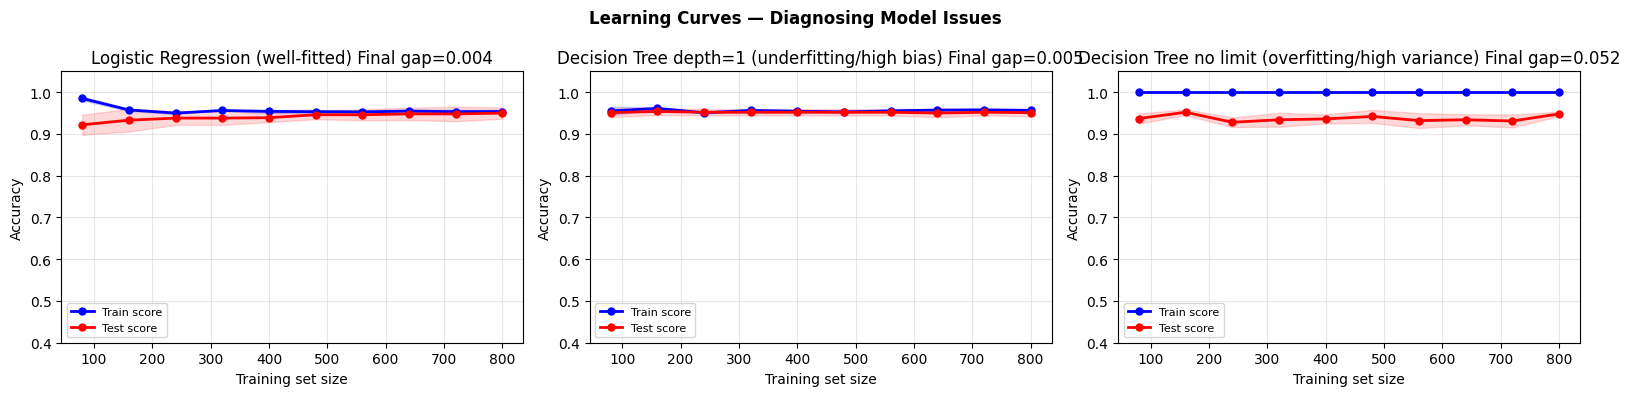

Reading learning curves:
  Blue (train) high, Red (test) high → underfitting, add complexity
  Blue high, Red low, BIG gap        → overfitting, regularize or get more data
  Both curves plateau                → getting more data won't help


In [28]:
from sklearn.model_selection import learning_curve

X, y = make_classification(n_samples=1000, n_features=10, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

configs = [
    (LogisticRegression(max_iter=1000),'Logistic Regression (well-fitted)'),
    (DecisionTreeClassifier(max_depth=1),'Decision Tree depth=1 (underfitting/high bias)'),
    (DecisionTreeClassifier(max_depth=None),'Decision Tree no limit (overfitting/high variance)'),
]

for ax, (model, title) in zip(axes, configs):
    train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
          model,
          X,
          y,
          cv=5,
          n_jobs=-1,
          train_sizes=np.linspace(0.1, 1.0, 10),
          scoring='accuracy',
          return_times=True
        )

    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    te_mean = test_scores.mean(axis=1)
    te_std  = test_scores.std(axis=1)

    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='blue')
    ax.fill_between(train_sizes, te_mean-te_std, te_mean+te_std, alpha=0.15, color='red')
    ax.plot(train_sizes, tr_mean, 'b-o', ms=5, lw=2, label='Train score')
    ax.plot(train_sizes, te_mean, 'r-o', ms=5, lw=2, label='Test score')

    gap = tr_mean[-1] - te_mean[-1]
    ax.set_title(f'{title} Final gap={gap:.3f}')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves — Diagnosing Model Issues', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Reading learning curves:")
print("  Blue (train) high, Red (test) high → underfitting, add complexity")
print("  Blue high, Red low, BIG gap        → overfitting, regularize or get more data")
print("  Both curves plateau                → getting more data won't help")


---
## 9. Evaluation for Deep Learning

Deep learning has extra evaluation concerns beyond accuracy metrics.

### Train / Validation / Test Split
```
All data
  ├── Train set (70-80%)      → model learns from this
  ├── Validation set (10-15%) → tune hyperparameters, stop early
  └── Test set (10-15%)       → final unbiased evaluation (use ONCE)
```

### Early Stopping
Monitor validation loss. Stop when it starts increasing — the model has started overfitting.

### Key DL-specific pitfalls:
- **Data leakage** — test data accidentally influencing training
- **Overfit to validation** — tuning too many hyperparameters on validation set
- **Using test set multiple times** — inflates reported performance

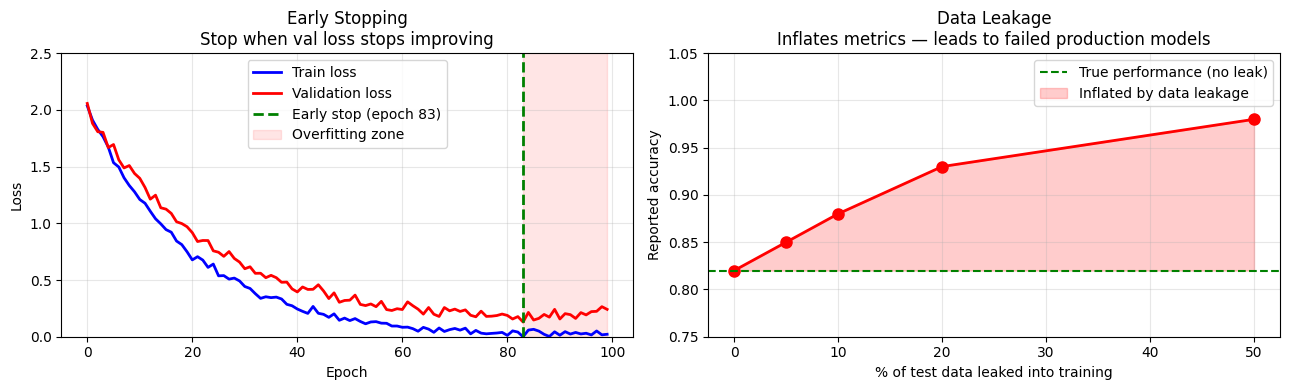

Early stopping best epoch: 83
Using model from epoch 83 prevents overfitting

DL evaluation checklist:
  ✓ Separate train / val / test (never mix)
  ✓ Use val set for hyperparameter tuning
  ✓ Use test set ONCE at the very end
  ✓ Check for data leakage (temporal splits, etc.)
  ✓ Report mean ± std across multiple seeds


In [29]:
# Simulate training curves with early stopping
np.random.seed(0)
epochs = 100

# Generate realistic loss curves
train_loss = 2.0 * np.exp(-epochs * np.linspace(0, 1, epochs) * 0.05)
train_loss += np.random.normal(0, 0.02, epochs)

# Val loss: decreases then increases (overfitting)
val_loss = 2.0 * np.exp(-epochs * np.linspace(0, 1, epochs) * 0.04)
val_loss += np.linspace(0, 0.3, epochs) ** 1.5  # overfitting component
val_loss += np.random.normal(0, 0.03, epochs)

best_epoch = np.argmin(val_loss)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_loss, 'b-', lw=2, label='Train loss')
axes[0].plot(val_loss, 'r-', lw=2, label='Validation loss')
axes[0].axvline(best_epoch, color='green', linestyle='--', lw=2,
                label=f'Early stop (epoch {best_epoch})')
axes[0].fill_between(range(best_epoch, epochs), 0, 3, alpha=0.1, color='red',
                    label='Overfitting zone')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Early Stopping\nStop when val loss stops improving')
axes[0].set_ylim(0, 2.5)
axes[0].legend()

# Data leakage example
leak_sizes = [0, 5, 10, 20, 50]  # % of test data leaked into training
leaked_acc = [0.82, 0.85, 0.88, 0.93, 0.98]  # inflated accuracy

axes[1].plot(leak_sizes, leaked_acc, 'r-o', lw=2, ms=8)
axes[1].axhline(0.82, color='green', linestyle='--', label='True performance (no leak)')
axes[1].fill_between(leak_sizes, 0.82, leaked_acc, alpha=0.2, color='red',
                    label='Inflated by data leakage')
axes[1].set_xlabel('% of test data leaked into training')
axes[1].set_ylabel('Reported accuracy')
axes[1].set_title('Data Leakage\nInflates metrics — leads to failed production models')
axes[1].legend()
axes[1].set_ylim(0.75, 1.05)

plt.tight_layout()
plt.show()

print("Early stopping best epoch:", best_epoch)
print("Using model from epoch", best_epoch, "prevents overfitting")
print()
print("DL evaluation checklist:")
print("  ✓ Separate train / val / test (never mix)")
print("  ✓ Use val set for hyperparameter tuning")
print("  ✓ Use test set ONCE at the very end")
print("  ✓ Check for data leakage (temporal splits, etc.)")
print("  ✓ Report mean ± std across multiple seeds")

---
## 10. Evaluation for LLMs & Generative AI

Evaluating generative models is fundamentally harder — there's no single right answer.

| Metric | What it measures | Used for |
|---|---|---|
| **Perplexity** | How well model predicts text | Language model quality |
| **BLEU** | N-gram overlap with reference | Machine translation |
| **ROUGE** | Recall-based overlap | Summarization |
| **FID** | Feature distribution similarity | Image generation |
| **Win rate** | Human preference A vs B | LLM alignment (RLHF) |
| **MMLU** | Knowledge benchmark | General capability |

> **The hard truth:** All automated metrics are imperfect proxies.  
> Human evaluation is the gold standard for LLM quality — but it's expensive.

=== BLEU Score (text generation quality) ===
Reference: 'The cat sat on the mat near the window'

  Good translation      : BLEU=0.667  'The cat sat on the mat'
  OK translation        : BLEU=0.333  'A cat was sitting on a mat'
  Bad translation       : BLEU=0.222  'The dog ran in the park yesterday'
  Degenerate            : BLEU=0.333  'the the the the the the the the'
 === Perplexity ===
  GPT-4 on common text               : PPL =      1.3
  GPT-4 on rare text                 : PPL =      3.3
  Small model                        : PPL =      8.1
  Random baseline (1/50k)            : PPL =  49999.8


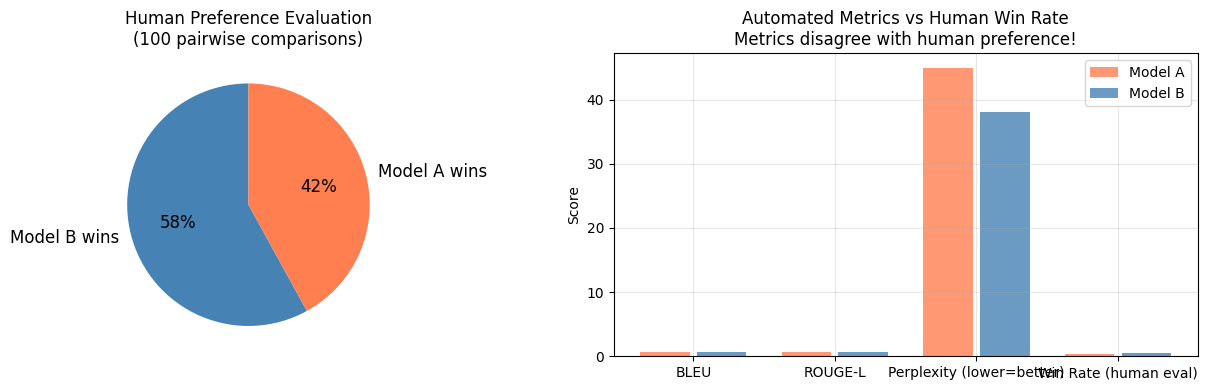


Key lesson: BLEU and ROUGE favor Model A, but humans prefer Model B.
Automated metrics are imperfect. Human evaluation is the ground truth.


In [30]:
from collections import Counter

# BLEU score — measures translation/generation quality
def bleu_1gram(reference, hypothesis):
    # Simplified unigram BLEU
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    ref_counts = Counter(ref_tokens)
    matches = sum(min(hyp_tokens.count(w), ref_counts[w]) for w in set(hyp_tokens))
    precision = matches / len(hyp_tokens) if hyp_tokens else 0
    # Brevity penalty
    bp = min(1.0, len(hyp_tokens) / len(ref_tokens)) if ref_tokens else 0
    return bp * precision

reference  = "The cat sat on the mat near the window"
hyp_good   = "The cat sat on the mat"
hyp_ok     = "A cat was sitting on a mat"
hyp_bad    = "The dog ran in the park yesterday"
hyp_repeat = "the the the the the the the the"

print("=== BLEU Score (text generation quality) ===")
print(f"Reference: '{reference}'")
print()
for hyp, name in [(hyp_good,'Good translation'),(hyp_ok,'OK translation'),
                  (hyp_bad,'Bad translation'),(hyp_repeat,'Degenerate')]:
    score = bleu_1gram(reference, hyp)
    print(f"  {name:22}: BLEU={score:.3f}  '{hyp}'")

# Perplexity comparison
def perplexity_from_probs(token_probs):
    return np.exp(-np.mean(np.log(np.array(token_probs) + 1e-10)))

print(" === Perplexity ===")
scenarios = [
    ("GPT-4 on common text",    [0.7, 0.8, 0.6, 0.9, 0.75]),
    ("GPT-4 on rare text",      [0.3, 0.4, 0.2, 0.35, 0.3]),
    ("Small model",             [0.1, 0.15, 0.08, 0.2, 0.12]),
    ("Random baseline (1/50k)", [1/50000]*5),
]
for name, probs in scenarios:
    ppl = perplexity_from_probs(probs)
    print(f"  {name:35}: PPL = {ppl:8.1f}")

# Win rate simulation (human preference evaluation)
np.random.seed(1)
n_comparisons = 100
model_a_wins = 42  # out of 100 comparisons
model_b_wins = 58
ties = 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels_pie = ['Model B wins', 'Model A wins']
sizes = [model_b_wins, model_a_wins]
colors_pie = ['steelblue', 'coral']
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize':12})
axes[0].set_title(f'Human Preference Evaluation\n({n_comparisons} pairwise comparisons)')

metrics = ['BLEU', 'ROUGE-L', 'Perplexity (lower=better)', 'Win Rate (human eval)']
model_a = [0.72, 0.68, 45, 0.42]
model_b = [0.69, 0.71, 38, 0.58]
x = np.arange(len(metrics))
axes[1].bar(x-0.2, model_a, 0.35, label='Model A', color='coral', alpha=0.8)
axes[1].bar(x+0.2, model_b, 0.35, label='Model B', color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Automated Metrics vs Human Win Rate\nMetrics disagree with human preference!')
axes[1].legend()
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()
print("\nKey lesson: BLEU and ROUGE favor Model A, but humans prefer Model B.")
print("Automated metrics are imperfect. Human evaluation is the ground truth.")

---
## Summary — Evaluation Across the Stack

```
Classic ML
  └── Confusion matrix           → Where are the errors?
  └── Precision / Recall         → Imbalanced classes
  └── AUC-ROC                    → Threshold-independent classifier ranking
  └── RMSE / R²                  → Regression quality
  └── Cross-validation           → Reliable generalization estimate
  └── Bias-variance tradeoff     → Diagnose under/overfitting
  └── Learning curves            → Is more data the answer?

Deep Learning
  └── Train/val/test split       → Never contaminate test set
  └── Early stopping             → Stop when val loss plateaus
  └── Data leakage detection     → Most common cause of inflated metrics

LLMs & Generative AI
  └── Perplexity                 → Text prediction quality
  └── BLEU / ROUGE               → Translation / summarization overlap
  └── FID                        → Image generation quality
  └── Win rate (human eval)      → Ground truth — but expensive
```

| Metric | Use when | Never use when |
|---|---|---|
| Accuracy | Classes balanced | Imbalanced dataset |
| F1 | Imbalanced, both P and R matter | Regression |
| AUC-ROC | Comparing classifiers overall | Comparing at a specific threshold |
| RMSE | Penalize large errors | Outliers are unavoidable |
| MAE | Outliers expected | Need to penalize large errors |
| Cross-val | Always, for final evaluation | Exploratory/quick checks |
| Perplexity | Language model quality | Image or structured generation |
| BLEU/ROUGE | Translation/summarization | Open-ended generation |
| Human eval | LLM quality | When scale or budget prohibit it |

### What to learn next
- **regression.ipynb** → apply these metrics on your first Kaggle dataset
- **decision_trees.ipynb** → see bias-variance tradeoff with tree depth
- **model_selection.ipynb** → grid search, hyperparameter tuning